### 1. **Introduction**
#### This project focuses on building a Disease Prediction System using machine learning techniques. The objective is to predict the type of disease   based on patient symptoms and health-related attributes such as age, blood pressure, and cholesterol level. This system can help in early etection and provide basic insights into possible health conditions.


### 2. **Dataset Description**
#### The dataset contains both symptom-based and health-related features. The columns included are: 
#### Disease: Target variable representing the type of disease
#### Fever: Indicates presence of fever (0 = No, 1 = Yes)
#### Cough: Indicates presence of cough
#### Fatigue: Indicates tiredness
#### Difficulty Breathing: Breathing issues
#### Age: Age of the patient
#### Gender: Male/Female
#### Blood Pressure: Patient’s blood pressure level
#### Cholesterol Level: Cholesterol measurement
#### Outcome Variable: Represents the condition (Recovered / At Risk / Severe)



### 3. **Data Preprocessing**
#### Before analysis, the dataset was cleaned and prepared:

#### Missing values were checked and handled
#### Categorical variables like Gender were encoded into numerical format
#### Data types were verified and corrected
#### Duplicate records were removed


### 4. **Exploratory Data Analysis (EDA)**
#### Exploratory Data Analysis was performed to understand the dataset and identify patterns.


#####  4.1 **Disease Distribution**
###### The frequency of each disease was analyzed to identify the most common conditions in the dataset.

##### 4.2 **Symptom Analysis**
###### Symptoms such as fever, cough, and fatigue were analyzed to determine their relationship with different diseases.

##### 4.3 **Age Analysis**
###### The average age of patients for each disease was examined to identify age-related patterns.

##### 4.4 **Gender Analysis**
###### The distribution of diseases among male and female patients was analyzed.

##### 4.5 **Blood Pressure Analysis**
###### The impact of blood pressure on disease occurrence was studied.

##### 4.6 **Cholesterol Analysis**
###### The relationship between cholesterol levels and diseases was explored.

##### 4.7 **Outcome Analysis**
###### The outcome variable was analyzed to understand recovery rates and severity levels.


### 5. **Data Visualization**
#### Various visualizations were used to better understand the data:

#### Bar charts for disease distribution
#### Heatmaps for correlation analysis
#### Count plots for categorical variables
#### Histograms for numerical features


### 6. **Model Building**
#### A machine learning model was built to predict diseases.

#### Features (X): All columns except Disease
#### Target (y): Disease

#### Algorithms used:
#### Decision Tree Classifier
#### Random Forest Classifier

### 7. **Model Evaluation**
#### The model performance was evaluated using:

#### Accuracy Score
#### Confusion Matrix
#### The model showed good performance in predicting diseases based on input features.

### 8. **Conclusion**
#### The project successfully demonstrated that machine learning can be used to predict diseases based on symptoms and patient data. Symptoms like fever and cough were found to be strong indicators of certain diseases.

### 9. **Limitations**
#### The dataset is limited and may not represent real-world medical data
#### The model is not suitable for real medical diagnosis
#### Accuracy depends on data quality


### 10. **Future Scope**
#### Integration with real-time healthcare data
#### Deployment using web frameworks like FastAPI
#### Adding more features such as medical history
#### Improving model accuracy with advanced algorithms

#### 1. Import All Libraries and Read Csv File :

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(12,6))

# remove extra warning :
import warnings
warnings.filterwarnings('ignore')


import numpy as np 
import plotly.express as px

from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split

# make a pipe line
from sklearn.pipeline import Pipeline
# model and encoding :
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder,StandardScaler
le = LabelEncoder()

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
# check words distribution
from wordcloud import WordCloud,STOPWORDS

# check quick summary and info of the data in the html formate
# ! pip install  ydata-profiling

# applying the xgboost
from xgboost import XGBClassifier

# save model
import joblib

df = pd.read_csv('Disease_symptom_and_patient_profile_dataset.csv')
print(df.head)

# show quick summary using ydata-profiling :
from ydata_profiling import ProfileReport
report = ProfileReport(df)
# show in notebook :
report.to_notebook_iframe()

# save this file in html formate :
report.to_file('quick summary of disease.html')

<bound method NDFrame.head of          Disease Fever Cough Fatigue Difficulty Breathing  Age  Gender  \
0      Influenza   Yes    No     Yes                  Yes   19  Female   
1    Common Cold    No   Yes     Yes                   No   25  Female   
2         Eczema    No   Yes     Yes                   No   25  Female   
3         Asthma   Yes   Yes      No                  Yes   25    Male   
4         Asthma   Yes   Yes      No                  Yes   25    Male   
..           ...   ...   ...     ...                  ...  ...     ...   
344       Stroke   Yes    No     Yes                   No   80  Female   
345       Stroke   Yes    No     Yes                   No   85    Male   
346       Stroke   Yes    No     Yes                   No   85    Male   
347       Stroke   Yes    No     Yes                   No   90  Female   
348       Stroke   Yes    No     Yes                   No   90  Female   

    Blood Pressure Cholesterol Level Outcome Variable  
0              Low       

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 170.92it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#### 2. Uderstand the data and cleaning also :

In [2]:
print(df.head(4))
# check the all information between data :
print("\nTotal duplicates values in the data = ", df.duplicated().sum())

print("Check stats of the data = \n",df.describe())

print("\n check the null value in the data\n",df.isna().sum())

print(df.info())

# clean dataset :
df = df.drop_duplicates(keep='last')
print("\nTotal duplicates values in the data = ", df.duplicated().sum())


# class male and female :
print("Show the class of the Gender")
print(df['Gender'].value_counts(normalize=True)*100)

       Disease Fever Cough Fatigue Difficulty Breathing  Age  Gender  \
0    Influenza   Yes    No     Yes                  Yes   19  Female   
1  Common Cold    No   Yes     Yes                   No   25  Female   
2       Eczema    No   Yes     Yes                   No   25  Female   
3       Asthma   Yes   Yes      No                  Yes   25    Male   

  Blood Pressure Cholesterol Level Outcome Variable  
0            Low            Normal         Positive  
1         Normal            Normal         Negative  
2         Normal            Normal         Negative  
3         Normal            Normal         Positive  

Total duplicates values in the data =  49
Check stats of the data = 
               Age
count  349.000000
mean    46.323782
std     13.085090
min     19.000000
25%     35.000000
50%     45.000000
75%     55.000000
max     90.000000

 check the null value in the data
 Disease                 0
Fever                   0
Cough                   0
Fatigue               

#### 3. Exploratory Data Analysis

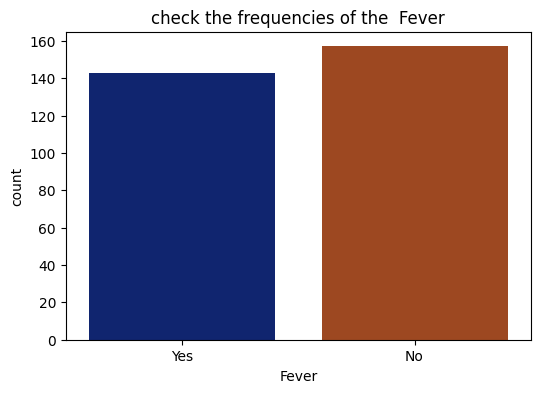

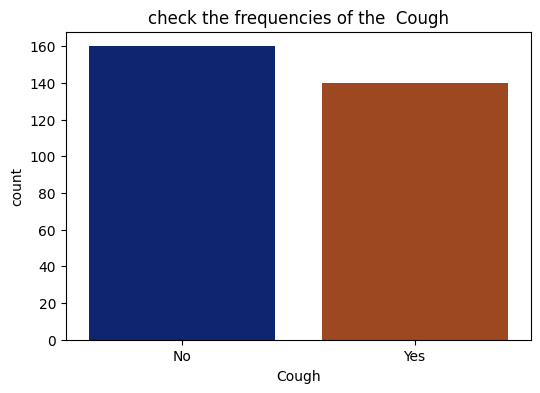

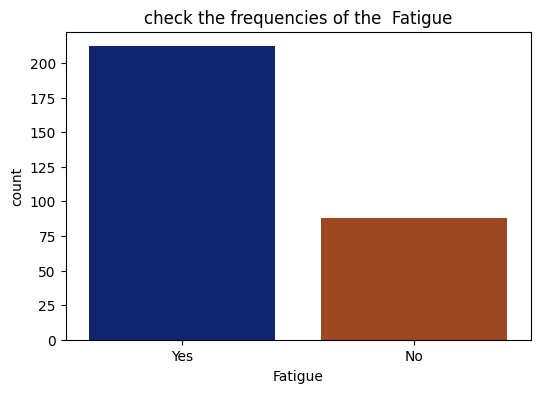

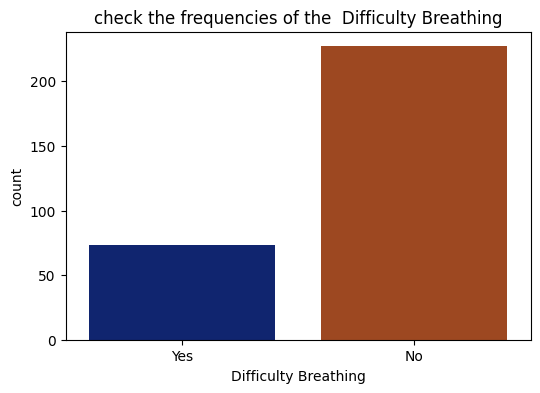

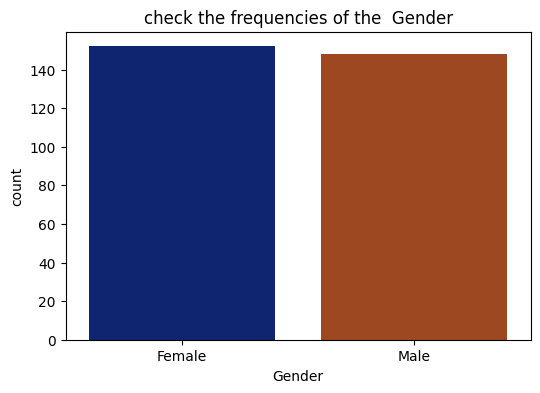

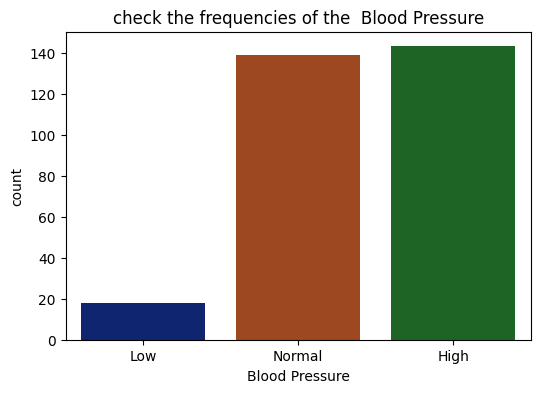

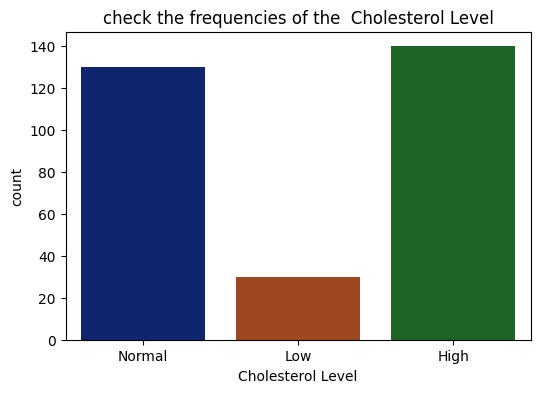

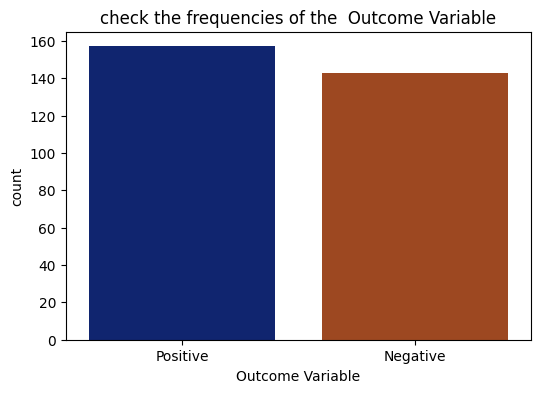

In [3]:
# Univariate Analysis :

col = ['Fever','Cough','Fatigue','Difficulty Breathing','Gender','Blood Pressure','Cholesterol Level','Outcome Variable']

for graphs in col:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df,
                 palette='dark',
                 x = graphs)
    plt.title(f"check the frequencies of the  {graphs}")
    plt.xlabel(f"{graphs}")
    plt.ylabel("count")
    plt.show()


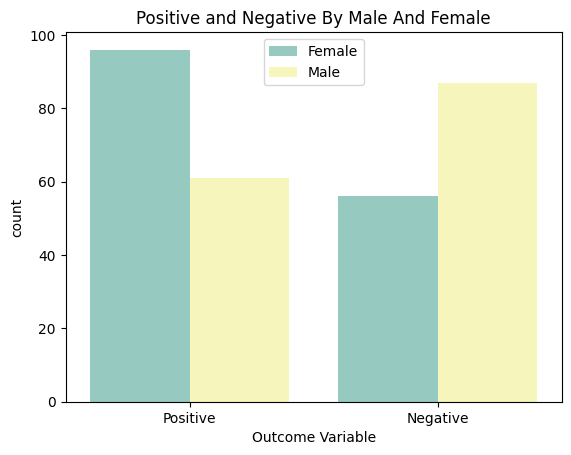

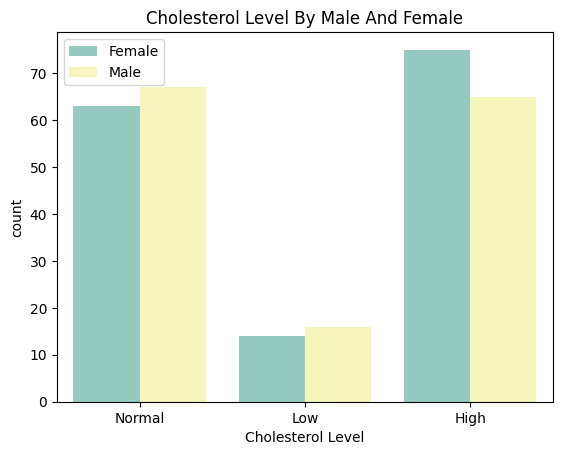

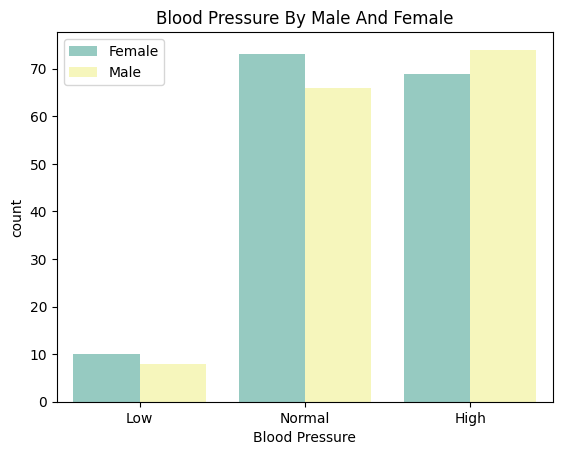

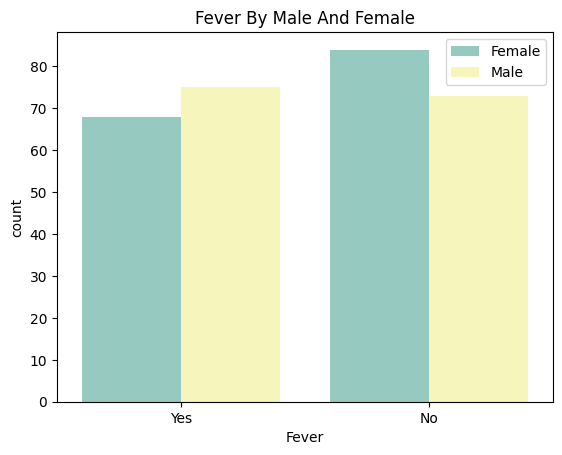

In [4]:
# Bivariate Analysis :
sns.countplot(data=df,
             x='Outcome Variable',
             hue='Gender',palette='Set3')
plt.title("Positive and Negative By Male And Female")
plt.legend()
plt.show()
	
sns.countplot(data=df,
             x='Cholesterol Level',
             hue='Gender',palette='Set3')
plt.title("Cholesterol Level By Male And Female")
plt.legend()
plt.show()


sns.countplot(data=df,
             x='Blood Pressure',
             hue='Gender',palette='Set3')
plt.title("Blood Pressure By Male And Female")
plt.legend()
plt.show()


sns.countplot(data=df,
             x='Fever',
             hue='Gender',palette='Set3')
plt.title("Fever By Male And Female")
plt.legend()
plt.show()

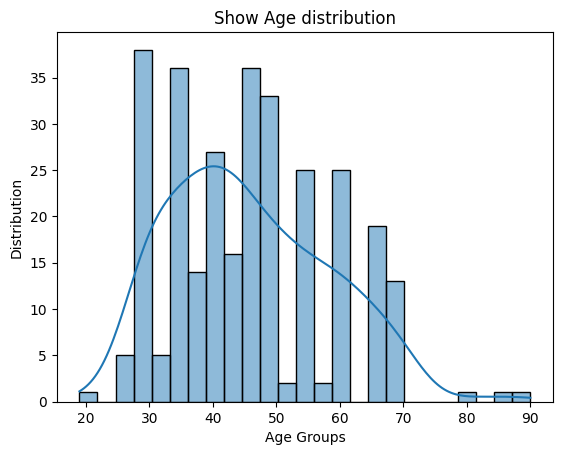

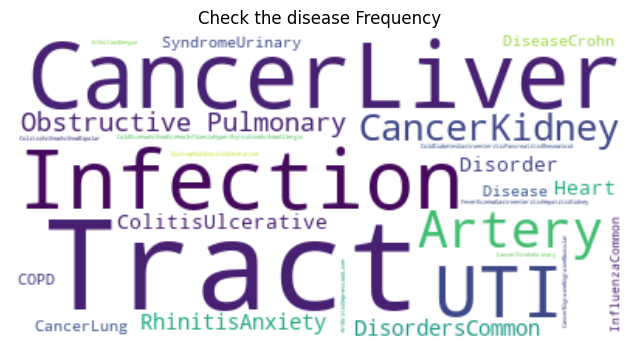

In [5]:
# Check teh age distribution :
sns.histplot(data=df,
            x='Age',bins=25,
            kde=True,fill=True,)
plt.title("Show Age distribution")
plt.xlabel("Age Groups")
plt.ylabel("Distribution")
plt.show()

# check the Disease Frequencies  using word cloud:
plt.figure(figsize=(8,7))
text = "".join(df['Disease'])
sw = STOPWORDS
wc = WordCloud(stopwords=sw,
              background_color='white',margin=5,
              random_state=42).generate(text)

plt.imshow(wc,interpolation='bilinear')
plt.title("Check the disease Frequency")
plt.axis('off')
plt.show()

#### 4. Data Make a model friendly :

In [20]:
df['Outcome Variable'].value_counts(normalize=True)*100

Outcome Variable
1    52.333333
0    47.666667
Name: proportion, dtype: float64

In [18]:
df.head(1)

,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Yes,No,Yes,Yes,19,Female,Low,Normal,1


##### “The dataset contains a large number of disease categories with very few samples per class, which makes it difficult for the model to learn effectively. To address this, I either used binary classification or grouped diseases into broader categories to improve performance.”

In [9]:
# drop Disease column :
df = df.drop('Disease',axis=1)

#### 5. Split the data 

In [15]:
df['Outcome Variable'] = df['Outcome Variable'].map({
    'Positive': 1,
    'Negative': 0
})
y = df['Outcome Variable']
X = df.drop('Outcome Variable', axis=1)

X = pd.get_dummies(X, drop_first=True).astype(int)

#### 6. Apply Model

In [46]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)

model_dt = DecisionTreeClassifier(criterion='gini',max_depth=15,min_samples_leaf=2,min_samples_split=5)

model_rf = RandomForestClassifier(n_estimators=200,min_samples_split=5,min_samples_leaf=2,max_depth=20,bootstrap=False)

model_dt.fit(X_train,y_train)
model_rf.fit(X_train,y_train)

dt_pred = model_dt.predict(X_test)
rf_pred = model_rf.predict(X_test)

In [77]:
xgb = XGBClassifier(n_estimators=300,
    learning_rate=0.1,   
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    random_state=42)

xgb.fit(X_train,y_train)
xgb_pred = xgb.predict(X_test)
print("XGB accuracy",accuracy_score(y_test,xgb_pred))

XGB accuracy 0.7444444444444445


### 7. Accuracy improve with HyperParameter Tuning :

##### 1. Decision Tree Find best Parameter

In [39]:
dt = DecisionTreeClassifier()

param = {
    'criterion': ['gini', 'entropy'],   # fixed
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    estimator=dt,
    param_grid=param,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5}


##### 2. RandomForest Find best Parameter

In [40]:
rf = RandomForestClassifier()
param = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}


grid = RandomizedSearchCV(estimator=rf,
                         param_distributions=param,scoring='accuracy',
                         n_jobs=-1,
                         n_iter=20,random_state=42)


grid.fit(X_train,y_train)
print(grid.best_params_)

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20, 'bootstrap': False}


##### 3. XG Boost Find best Parameter

In [75]:
xgb = XGBClassifier()

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

print("Best Params:", random.best_params_)

Best Params: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.7}


#### 8. Evaluate the model 

In [54]:
print("Tree accuracy is",accuracy_score(y_test,dt_pred))
print("random forest accuracy is",accuracy_score(y_test,rf_pred))

Tree accuracy is 0.7111111111111111
random forest accuracy is 0.7222222222222222


In [70]:
print("Tree confusion matrics\n",confusion_matrix(y_test,dt_pred))
print("Random Forest confusion matrics\n",confusion_matrix(y_test,rf_pred))
print("XGB confusion matrics\n",confusion_matrix(y_test,xgb_pred))

Tree confusion matrics
 [[34  6]
 [20 30]]
Random Forest confusion matrics
 [[29 11]
 [14 36]]
XGB confusion matrics
 [[27 13]
 [10 40]]


In [78]:
print("tree classification report\n",classification_report(y_test,dt_pred))
print("random forest reposrt\n",classification_report(y_test,rf_pred))
print("XG Boost reposrt\n",classification_report(y_test,xgb_pred))

tree classification report
               precision    recall  f1-score   support

           0       0.63      0.85      0.72        40
           1       0.83      0.60      0.70        50

    accuracy                           0.71        90
   macro avg       0.73      0.72      0.71        90
weighted avg       0.74      0.71      0.71        90

random forest reposrt
               precision    recall  f1-score   support

           0       0.67      0.72      0.70        40
           1       0.77      0.72      0.74        50

    accuracy                           0.72        90
   macro avg       0.72      0.72      0.72        90
weighted avg       0.73      0.72      0.72        90

XG Boost reposrt
               precision    recall  f1-score   support

           0       0.73      0.68      0.70        40
           1       0.75      0.80      0.78        50

    accuracy                           0.74        90
   macro avg       0.74      0.74      0.74        90
weigh

### 9. Threshold Tuning :

In [83]:
threshold_value = 0.3
y_prob = xgb.predict_proba(X_test)[:,1]
y_xgb = (y_prob>threshold_value).astype(int)
print("XG Boost \n",classification_report(y_test,y_xgb))

XG Boost 
               precision    recall  f1-score   support

           0       0.75      0.68      0.71        40
           1       0.76      0.82      0.79        50

    accuracy                           0.76        90
   macro avg       0.75      0.75      0.75        90
weighted avg       0.76      0.76      0.75        90



### 10. Using SMOT Technique to improve the model performance

In [87]:
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42)

# X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# xgb.fit(X_resampled, y_resampled)

# smote.fit_resample(X_test, y_test)

In [88]:
result = pd.DataFrame({
    "Model":["DecisionTree","RandomForest","XGB accuracy"],
    "Recall":[
        recall_score(y_test,dt_pred),
        recall_score(y_test,rf_pred),
        np.nan
    ],
    "Accuracy":[
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred)
    ],
    "Threshold_Tuning":[
        np.nan,
        np.nan,
        accuracy_score(y_test,y_xgb)
    ]
})

result

,Model,Recall,Accuracy,Threshold_Tuning
0,DecisionTree,0.60,0.711111,NaN
1,RandomForest,0.72,0.722222,NaN
2,XGB accuracy,NaN,0.744444,0.755556


### 11. Deployment the model :

In [89]:
try :
    with open ("model.pkl","wb") as file:
        joblib.dump(xgb,file)

    print("Model Successfully Save")
except Exception as e:
    print("Error Not save a Model",e)

Model Successfully Save
